perceptron.
$$
y =
\begin{cases}
0&(b + w_1x_1 + w_2x_2 \le 0) \\
1&(b + w_1x_1 + w_2x_2 > 0)
\end{cases}
$$

$$
y = h(b + w_1x_1 + w_2x_2)
$$
$$
h(x) = \begin{cases}
0&(x\le0) \\
1&(x>0)
\end{cases}
$$

$$
a = b + w_1x_1 + w_2x_2
$$
$$
y = h(a)
$$
function $h$ is called by activation function

sigmoid function
$$
h(x) = {1 \over 1 + \exp(-x)}
$$

In [6]:
def step_function(x):
    if x>0:
        return 1
    else:
        return 0

In [7]:
# using numpy for np.array
import numpy as np
def step_function(x):
    y = x>0
    return y.astype(np.int32)

In [8]:
x = np.array([-1.0, 1.0, 2.0])
print("x: ", x)
y = x > 0
print("y: ", y)
print(": ", step_function(x))

x:  [-1.  1.  2.]
y:  [False  True  True]
:  [0 1 1]


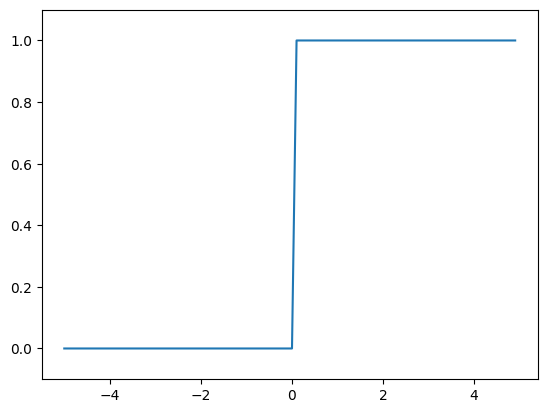

In [9]:
import numpy as np
import matplotlib.pylab as plt

def step_function(x):
    return np.array(x > 0, dtype=np.int32)
x = np.arange(-5.0, 5.0, 0.1)
y = step_function(x)
plt.plot(x, y)
plt.ylim(-0.1, 1.1)
plt.show()

In [10]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

In [11]:
x = np.array([-1.0, 1.0, 2.0])
sigmoid(x)

array([0.26894142, 0.73105858, 0.88079708])

(-0.1, 1.1)

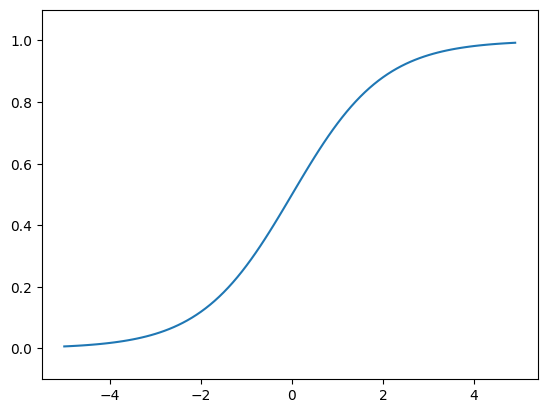

In [12]:
x = np.arange(-5.0, 5.0, 0.1)
y = sigmoid(x)
plt.plot(x, y)
plt.ylim(-0.1, 1.1)

(-0.1, 1.1)

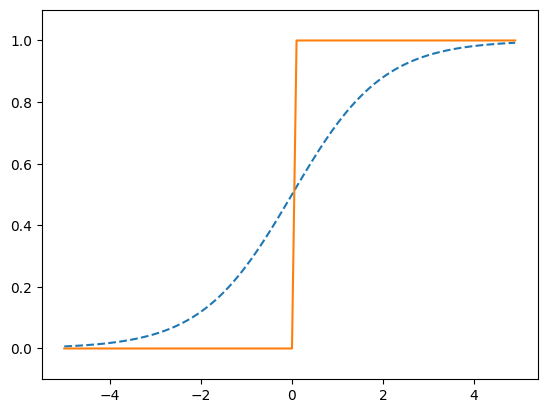

In [13]:
y_1 = sigmoid(x)
y_2 = step_function(x)
plt.plot(x, y_1, ls="--")
plt.plot(x, y_2)
plt.ylim(-0.1, 1.1)

(-0.1, 1.1)

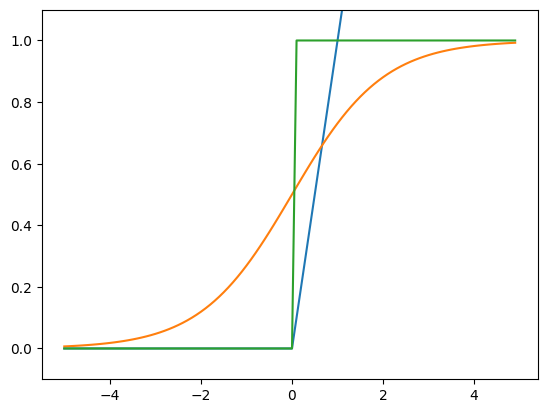

In [14]:
def relu(x):
    return np.maximum(0, x)

y_relu = relu(x)
y_sigmoid = sigmoid(x)
y_step = step_function(x)
plt.plot(x, y_relu)
plt.plot(x, y_sigmoid)
plt.plot(x, y_step)
plt.ylim(-0.1, 1.1)


In [15]:
X = np.array([1, 2])
print("X.shape: ", X.shape)
W = np.array([[1, 3, 5], [2, 4, 6]])
print("W.shape: ", W.shape)

Y = np.dot(X, W)
print("Y.shape: ", Y.shape)

X.shape:  (2,)
W.shape:  (2, 3)
Y.shape:  (3,)


3층 신경망

In [16]:
X = np.array([1.0, 0.5])
W1 = np.array([[0.1, 0.3, 0.5], [0.2, 0.4, 0.6]])
B1 = np.array([0.1, 0.2, 0.3])
print("W1.shape: ", W1.shape)
print("B1.shape: ", B1.shape)
print("X.shape: ", X.shape)

A1 = np.dot(X, W1) + B1
print("A1.shape: ", A1.shape)
print("A1: ", A1)

W1.shape:  (2, 3)
B1.shape:  (3,)
X.shape:  (2,)
A1.shape:  (3,)
A1:  [0.3 0.7 1.1]


In [17]:
Z1 = sigmoid(A1)
print("Z1.shape: ", Z1.shape)
print("Z1: ", Z1)

Z1.shape:  (3,)
Z1:  [0.57444252 0.66818777 0.75026011]


In [18]:
W2 = np.array([[0.1, 0.4], [0.2, 0.5], [0.3, 0.6]])
B2 = np.array([0.1, 0.2])

print("Z1.shape: ", Z1.shape)
print("B2.shape: ", B2.shape)
print("W2.shape: ", W2.shape)

A2 = np.dot(Z1, W2) + B2
Z2 = sigmoid(A2)
print("Z2.shape: ", Z2.shape)
print("Z2: ", Z2)

Z1.shape:  (3,)
B2.shape:  (2,)
W2.shape:  (3, 2)
Z2.shape:  (2,)
Z2:  [0.62624937 0.7710107 ]


In [19]:
def identity_function(x):
    return x
W3 = np.array([[0.1, 0.3], [0.2, 0.4]])
B3 = np.array([0.1, 0.2])

A3 = np.dot(Z2, W3) + B3
Y = identity_function(A3)
print("Y.shape: ", Y.shape)
print("Y: ", Y)

Y.shape:  (2,)
Y:  [0.31682708 0.69627909]


In [20]:
def init_network():
    network = {}
    network["W1"] = np.array([[0.1, 0.3, 0.5], [0.2, 0.4, 0.6]])
    network["B1"] = np.array([0.1, 0.2, 0.3])
    network["W2"] = np.array([[0.1, 0.4], [0.2, 0.5], [0.3, 0.6]])
    network["B2"] = np.array([0.1, 0.2])
    network["W3"] = np.array([[0.1, 0.3], [0.2, 0.4]])
    network["B3"] = np.array([0.1, 0.2])
    return network

def forward(network, x):
    W1, W2, W3 = network["W1"], network["W2"], network["W3"]
    b1, b2, b3 = network["B1"], network["B2"], network["B3"]

    a1 = np.dot(x, W1) + b1
    z1 = sigmoid(a1)
    a2 = np.dot(z1, W2) + b2
    z2 = sigmoid(a2)
    a3 = np.dot(z2, W3) + b3
    y = identity_function(a3)
    return y

network = init_network()
x = np.array([1.0, 0.5])
y = forward(network, x)
print("y: ", y)

y:  [0.31682708 0.69627909]


In [21]:
def softmax(a):
	exp_a = np.exp(a)
	sum_exp_a = np.sum(exp_a)
	y = exp_a/sum_exp_a
	return y

# MNIST

In [22]:
import os, sys
sys.path.append(os.pardir)
from dataset.mnist import load_mnist

(x_train, t_train), (x_test, t_test) = load_mnist(flatten=True, normalize=False)
print("x_train.shape: ", x_train.shape)
print("t_train.shape: ", t_train.shape)
print("x_test.shape: ", x_test.shape)
print("t_test.shape: ", t_test.shape)

x_train.shape:  (60000, 784)
t_train.shape:  (60000,)
x_test.shape:  (10000, 784)
t_test.shape:  (10000,)


In [23]:
import sys, os
import numpy as np
from dataset.mnist import load_mnist
from PIL import Image

def img_show(img):
    pil_img = Image.fromarray(np.uint8(img))
    pil_img.show()

(x_train, t_train), (x_test, t_test) = load_mnist(flatten=True, normalize=False)
img = x_train[0]
label = t_train[0]
print("label: ", label)

print("img.shape: ", img.shape)
img = img.reshape(28, 28)
print("converted img.shape: ", img.shape)
img_show(img)

label:  5
img.shape:  (784,)
converted img.shape:  (28, 28)


 ### 3.6.2 신경망의 추론 처리

In [28]:
import pickle

def get_data():
    (x_train, t_train), (x_test, t_test) = load_mnist(flatten=True, normalize=False)
    return x_test, t_test

def init_network():
    with open("./resources/ch03/sample_weight.pkl", 'rb') as f:
        network = pickle.load(f)
    return network

def predict(network, x):
    W1, W2, W3 = network["W1"], network["W2"], network["W3"]
    b1, b2, b3 = network["b1"], network["b2"], network["b3"]
    a1 = np.dot(x, W1) + b1
    z1 = sigmoid(a1)
    a2 = np.dot(z1, W2) + b2
    z2 = sigmoid(a2)
    a3 = np.dot(z2, W3) + b3
    y = softmax(a3)
    return y

x, t = get_data()
network = init_network()
accuracy_cnt = 0
for i in range(len(x)):
    y = predict(network, x[i])
    p = np.argmax(y)
    if p == t[i]:
        accuracy_cnt += 1

print("Accuracy:" + str(float(accuracy_cnt)/len(x)))

Accuracy:0.9207


/var/folders/zw/4klfck4105j6y2q9k5cfwnqw0000gn/T/ipykernel_82465/1956533664.py:2: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-x))


### 3.6.3 batch process

In [29]:
x, t = get_data()
network = init_network()
batch_size = 100
accuracy_cnt = 0

for i in range(0, len(x), batch_size):
    x_batch = x[i:i+batch_size]
    y_batch = predict(network, x_batch)
    p = np.argmax(y_batch, axis=1)
    accuracy_cnt += np.sum(p==t[i:i+batch_size])
print("Accuracy:" + str(float(accuracy_cnt)/len(x)))

Accuracy:0.9207


/var/folders/zw/4klfck4105j6y2q9k5cfwnqw0000gn/T/ipykernel_82465/1956533664.py:2: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-x))
